# Week 10 — Home exercise 1: One respondent out of 2,884

**Solution proposal.**

How much a single row is worth, and what to do when the answer is "quite a lot".

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

plt.style.use("ggplot")

survey = pd.read_csv("../data/survey_data.csv", sep=":")

print(survey.shape)
survey.head(3)

(2884, 7)


,respondentID,age,hourly_earnings,years_schooling,sex,sector,experience
0,1,50,109.357913,9,male,private,30
1,2,50,267.671518,15,male,public,26
2,3,46,193.239479,15,female,public,29


## 1. Looking at it first

In [2]:
earnings = survey["hourly_earnings"]

print("respondents:      ", len(survey))
print("earning < 10 DKK: ", (earnings < 10).sum())
print("earning > 1000 DKK:", (earnings > 1000).sum())
print()
print("minimum:", round(earnings.min(), 2))
print("median: ", round(earnings.median(), 1))
print("mean:   ", round(earnings.mean(), 1))
print("maximum:", round(earnings.max(), 1))

respondents:       2884
earning < 10 DKK:  1
earning > 1000 DKK: 6

minimum: 0.0
median:  193.1
mean:    214.0
maximum: 4479.8


**One person earning zero, six earning over 1,000, and a maximum of 4,479.8** against a median of
193.1. The mean sits 11% above the median, which is the signature of a right tail.

Seven rows out of 2,884 is 0.24% of the data. Hold on to that number.

## 2. Earnings by sex and sector

In [3]:
by_group = survey.groupby(["sex", "sector"]).agg(
    respondents=("hourly_earnings", "size"),
    mean_earnings=("hourly_earnings", "mean"),
    median_earnings=("hourly_earnings", "median"),
).round(1)

by_group

respondents  mean_earnings  median_earnings
sex    sector                                              
female private          612          209.6            196.5
       public           894          194.3            182.2
male   private          999          234.4            205.5
       public           379          214.1            200.0

Men earn more than women in both sectors, and the private sector pays more than the public sector for
both. The gap between the highest and lowest cell is about 40 DKK an hour.

Note that the mean and the median disagree about *how much*, and the mean is the one being dragged
around by the tail. Reporting both costs one line and is worth it.

## 3. The distribution

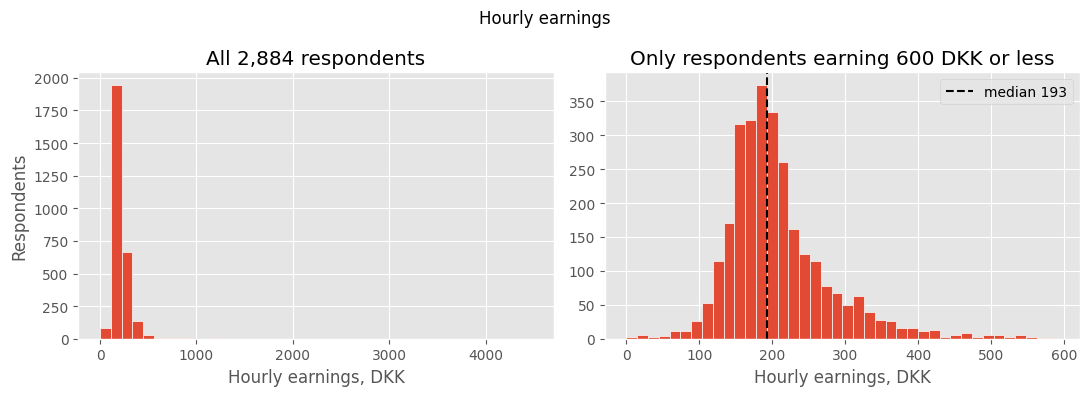

In [4]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(11, 4))

axes[0].hist(earnings, bins=40, edgecolor="white")
axes[0].set_title("All 2,884 respondents")
axes[0].set_xlabel("Hourly earnings, DKK")
axes[0].set_ylabel("Respondents")

axes[1].hist(earnings[earnings <= 600], bins=40, edgecolor="white")
axes[1].axvline(earnings.median(), color="black", linestyle="--",
                label=f"median {earnings.median():.0f}")
axes[1].set_title("Only respondents earning 600 DKK or less")
axes[1].set_xlabel("Hourly earnings, DKK")
axes[1].legend()

fig.suptitle("Hourly earnings")
fig.tight_layout()

plt.show()

### Which one would I show?

**The second, with the first available.**

The full-range histogram is not wrong, it is just useless: 99% of the data is squashed into the first
two bars, and the only thing you can read off it is that somebody earns 4,479 DKK an hour. The limited
version shows the shape of the distribution that nearly everybody is in.

But dropping the tail from the picture hides it, and the tail is real. So the honest version says so
— in the caption, in the title, or by showing both. **Cutting the range is a claim that what you cut
does not matter, and here it does**, as the rest of this exercise is about to show.

## 4. A function that returns one coefficient

In [5]:
def get_beta(data, formula, variable):
    """
    Fit an OLS model and return the coefficient on one variable.

    Parameters
    ----------
    data : DataFrame
        The data to fit the model on.
    formula : str
        An R-style model formula, for example "y ~ x1 + x2".
    variable : str
        Name of the term whose coefficient to return. Must appear in the
        fitted model, spelled the way statsmodels spells it.

    Returns
    -------
    float
        The estimated coefficient.

    Raises
    ------
    KeyError
        If variable is not a term in the fitted model.
    """
    results = smf.ols(formula, data=data).fit()

    return results.params[variable]

In [6]:
formula = "hourly_earnings ~ years_schooling + experience + I(experience**2)"

baseline_beta = get_beta(survey, formula, "years_schooling")

print("coefficient on years_schooling:", round(baseline_beta, 4))

coefficient on years_schooling: 13.7673


**13.77 DKK per hour for each additional year of schooling**, holding experience constant.

## 5. Leaving one respondent out, 2,884 times

The loop refits the model once per row, each time on everything except that row. Two things make it
manageable: the function above hides the fitting, and a boolean mask does the dropping.

In [7]:
betas = []

for i in survey.index:
    without_i = survey[survey.index != i]
    betas.append(get_beta(without_i, formula, "years_schooling"))

betas = pd.Series(betas, index=survey.index)

print("models fitted:", len(betas))
print()
print("smallest coefficient:", round(betas.min(), 4))
print("largest coefficient: ", round(betas.max(), 4))
print("full model:          ", round(baseline_beta, 4))

models fitted: 2884

smallest coefficient: 13.2408
largest coefficient:  13.8873
full model:           13.7673


In [8]:
shift = (betas - baseline_beta).abs()
most_influential = shift.idxmax()

print("dropping row", most_influential, "moves the coefficient from",
      round(baseline_beta, 3), "to", round(betas[most_influential], 3))
print("that is a change of", round(shift[most_influential] / baseline_beta * 100, 1), "percent")
print()
survey.loc[[most_influential]]

dropping row 1173 moves the coefficient from 13.767 to 13.241
that is a change of 3.8 percent



,respondentID,age,hourly_earnings,years_schooling,sex,sector,experience
1173,1174,60,4479.768786,15,female,public,40


**One respondent moves the coefficient by nearly 4%.**

Respondent 1174 is a 60-year-old woman in the public sector with 15 years of schooling and 40 years of
experience, earning **4,479.8 DKK an hour** — about 23 times the median. She is the maximum from
question 1, and with 15 years of schooling she is at the median of that variable, so the model reads
her as evidence that schooling pays enormously.

Take her out and the estimated return to a year of schooling falls from **13.77 to 13.24 DKK**.

## 6. Robust or fragile?

**Robust, and only just — and the exercise is the point rather than the answer.**

The whole leave-one-out range is 13.24 to 13.89, a spread of 0.65 DKK around an estimate of 13.77.
Nobody would tell a different story about schooling at 13.2 than at 13.9, so the *conclusion* survives
any single respondent. That is the reassuring reading.

The unreassuring one is that a single row out of 2,884 moves the headline number by 4%, and that row is
not a mistake — she is a real respondent with a plausible-looking record. With 300 rows instead of
2,884, the same person would have moved it by ten times as much.

### What would I do about her?

**Not delete her.** She is not a data-entry error as far as anything here can tell, and dropping the
observations that disagree with you is how you get an analysis that always agrees with you.

What I would actually do, in order:

1. **Check whether it is a unit problem.** 4,479 DKK an hour is eight to nine million a year at any plausible number of working hours. That is
   possible and it is much more likely to be a monthly figure in an hourly column. Nothing in this
   file settles it, and that is the first thing to ask whoever supplied the data.
2. **Report the model both ways.** One column with all 2,884 respondents, one excluding the handful
   above 1,000, side by side in the regression table from the lecture. If they tell the same story,
   the reader stops worrying. If they do not, the reader needs to know.
3. **Say what I did.** "Excluding seven respondents earning under 10 or over 1,000 DKK per hour" is one
   sentence in a footnote, and it is the difference between a defensible choice and a hidden one.

What I would **not** do is what is easiest: fit the model once, quote 13.77, and never find out.

### Things worth noticing

- **`survey[survey.index != i]` rather than `.drop()`.** A boolean mask on the index does the job with
  tools you already have, and it makes obvious that the loop builds a new table each time rather than
  chipping away at the original.
- **The function is what makes the loop readable.** Three lines of fitting inside a 2,884-iteration
  loop would bury the one idea the loop contains. This is the same argument as the plotting function
  last week, on a different kind of output.
- **`(betas - baseline_beta).abs().idxmax()`** finds the row whose removal matters most without a
  second loop — vectorized arithmetic on a Series, from the start of Part 2.

### What this notebook does NOT do

- **It only ever removes one row at a time.** Seven respondents earn over 1,000 DKK; removing them
  *together* would move the coefficient much further than removing any one of them, and this loop
  cannot see that.
- **It says nothing about why schooling and earnings move together.** Higher earners may have studied
  longer, or the people who study longer may have been going to earn more anyway. The coefficient is
  the same either way.
- **The experience term is in the model and never examined.** `I(experience**2)` is there because the
  exercise asked for it, and no one checked whether it earns its place.